In [195]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
from nltk.corpus import stopwords
import nltk 
nltk.download("stopwords")

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

[nltk_data] Downloading package stopwords to C:\Users\ASUS
[nltk_data]     ZENBOOK\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Import Data

In [196]:
data_path = "Data/Restaurant_ABSA.xlsx"
df = pd.read_excel(data_path)
df.head()

,Id,Comment,"{Aspect category, Sentiment Polarity}"
0,1,খাবারটি অত্যন্ত সুস্বাদু ছিল কিন্তু দাম বেশি ছিল,"{food, positive}, {price, negative}"
1,2,যদিও খাদ্য ভাল ছিল কিন্তু পরিবেষনা ছিল বাজে।।,"{food, positive}, {service, negative}"
2,3,খাদ্যে সবসময় তাজা স্বাদ এবং তাত্ক্ষণিকভাবে পরিবেশিত।,"{food, positive}, {service, positive}"
3,4,খুব ভাল দাম এবং খুব ভাল সেবা।,"{price, positive}, {service, positive}"
4,5,"এটি একটি চমত্কার শিথিল জায়গা, এখনের খাদ্য ভাল ।","{ambiance, positive}, {food, positive}"


## Translate reviews to English

In [197]:
from deep_translator import GoogleTranslator
def translate_text(text):
    try:
        return GoogleTranslator(source='auto', target='en').translate(text)
    except:
        return text

In [198]:
new_data_path = re.sub("xlsx", "csv", data_path)
new_data_path

'Data/Restaurant_ABSA.csv'

In [199]:
if(re.sub("Data/", "", new_data_path) not in os.listdir("Data")):
    df['review_en'] = df['Comment'].apply(translate_text)

    df.to_csv(new_data_path, index=False)
    print("Saved: ", new_data_path)
else:
    df = pd.read_csv(new_data_path)

## Preprocessing

In [200]:
df.head()

,Id,Comment,"{Aspect category, Sentiment Polarity}",review_en
0,1,খাবারটি অত্যন্ত সুস্বাদু ছিল কিন্তু দাম বেশি ছিল,"{food, positive}, {price, negative}",The food was very tasty but the price was high
1,2,যদিও খাদ্য ভাল ছিল কিন্তু পরিবেষনা ছিল বাজে।।,"{food, positive}, {service, negative}",Although the food was good but the ambience was bad.
2,3,খাদ্যে সবসময় তাজা স্বাদ এবং তাত্ক্ষণিকভাবে পরিবেশিত।,"{food, positive}, {service, positive}",Food always tastes fresh and served promptly.
3,4,খুব ভাল দাম এবং খুব ভাল সেবা।,"{price, positive}, {service, positive}",Very good price and very good service.
4,5,"এটি একটি চমত্কার শিথিল জায়গা, এখনের খাদ্য ভাল ।","{ambiance, positive}, {food, positive}","It's a pretty relaxing place, now the food is good."


- Rename column for easier retriveval

In [201]:
df = df.rename(columns={"{Aspect category,   Sentiment Polarity}" : "sentiment_detail"})
df = df[["review_en", "sentiment_detail"]]

- Parse sentiment data to list of (aspect, sentiment)

In [202]:
def parse_sentiment(text):
    if not isinstance(text, str):
        print(text)
        return []
    return re.findall(r"\{([^,]+),\s*(positive|negative)\}", text)
df['aspect_sentiment'] = df['sentiment_detail'].apply(parse_sentiment)

- Explode dataframe by sentiment detail and split into 2 columns: aspect and sentiment

In [203]:
df = df.explode('aspect_sentiment')

df = df[df['aspect_sentiment'].notna()]

df['aspect'] = df['aspect_sentiment'].apply(lambda x: x[0])

In [204]:
df['aspect'].unique()

array(['food', 'price', 'service', 'ambiance', 'miscellaneous', 'serice'],
      dtype=object)

In [205]:
df.loc[df['aspect'] == 'serice', 'aspect'] = 'service'

In [206]:
df['sentiment'] = df['aspect_sentiment'].apply(lambda x: x[1])
df['sentiment'] = df['sentiment'].str.strip()

In [207]:
print(df['sentiment'].unique())

['positive' 'negative']


- Use `review_en`, `aspect` and `sentiment`

In [ ]:
df = df[["Comment", "review_en", "aspect", "sentiment"]]
df.head()

,review_en,aspect,sentiment
0,The food was very tasty but the price was high,food,positive
0,The food was very tasty but the price was high,price,negative
1,Although the food was good but the ambience was bad.,food,positive
1,Although the food was good but the ambience was bad.,service,negative
2,Food always tastes fresh and served promptly.,food,positive


- Check for null and duplicated data

In [209]:
df.isna().sum()

review_en    0
aspect       0
sentiment    0
dtype: int64

In [210]:
df = df.drop_duplicates()
df[df.duplicated()]

,review_en,aspect,sentiment


- Clean reviews:
  - lower text
  - remove special characters
  - remove extra spaces

In [211]:
# Preload stop words to avoid reloading them every time the function is called
stop_words = set(stopwords.words('english'))


def remove_stopwords(text):
    # Removing stop words from the text
    filtered_words = [word for word in text.split() if word not in stop_words]
    cleaned_text = ' '.join(filtered_words)

    return cleaned_text

In [212]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    # text = remove_stopwords(text)
    return text

df['review_en'] = df['review_en'].apply(clean_text)

- Label encoding for sentiment

In [213]:
label_map = {
    'negative': 0,
    'positive': 1
}

df['sentiment_encoded'] = df['sentiment'].map(label_map)

- One-hot encoding for aspect

In [214]:
onehot = pd.get_dummies(df['aspect'], prefix='aspect')
df = pd.concat([df, onehot], axis=1)

In [215]:
df.sample(1)

,review_en,aspect,sentiment,sentiment_encoded,aspect_ambiance,aspect_food,aspect_miscellaneous,aspect_price,aspect_service
429,i dont understand how the staff of the restaurant handled so many customers and the atmosphere of the restaurant was very quiet even though there were many people,service,positive,1,False,False,False,False,True


## EDA

In [216]:
label_count = df['sentiment'].value_counts()
label_count

sentiment
positive    851
negative    641
Name: count, dtype: int64

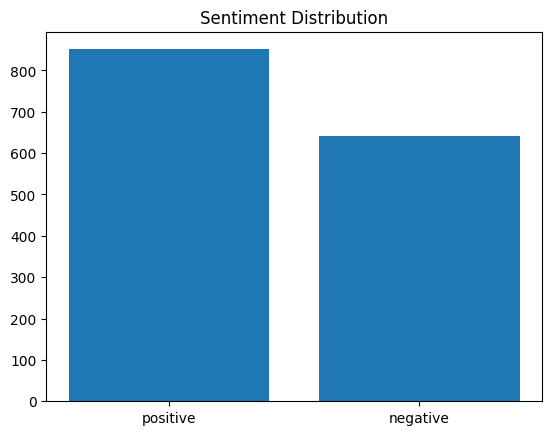

In [217]:
plt.bar(label_count.index, label_count.values)
plt.title("Sentiment Distribution")
plt.show()

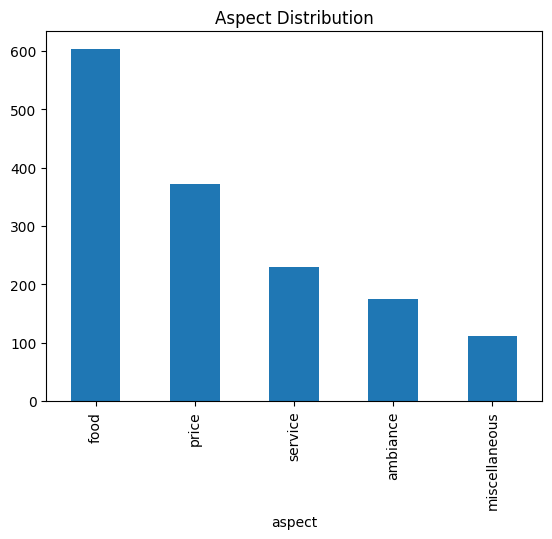

In [218]:
df['aspect'].value_counts().plot(kind='bar')
plt.title("Aspect Distribution")
plt.show()

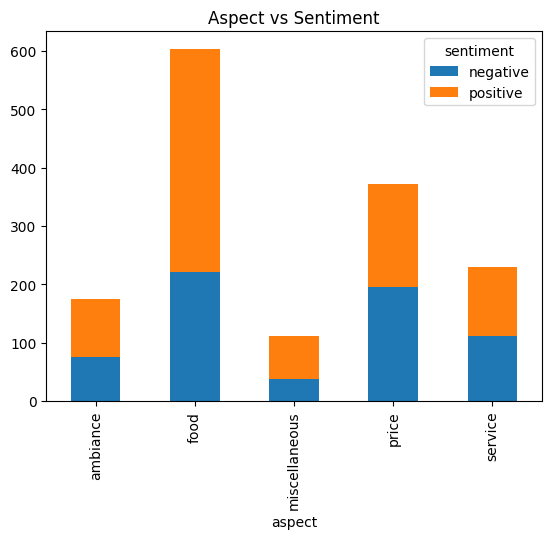

In [219]:
pd.crosstab(df['aspect'], df['sentiment']).plot(kind='bar', stacked=True)
plt.title("Aspect vs Sentiment")
plt.show()

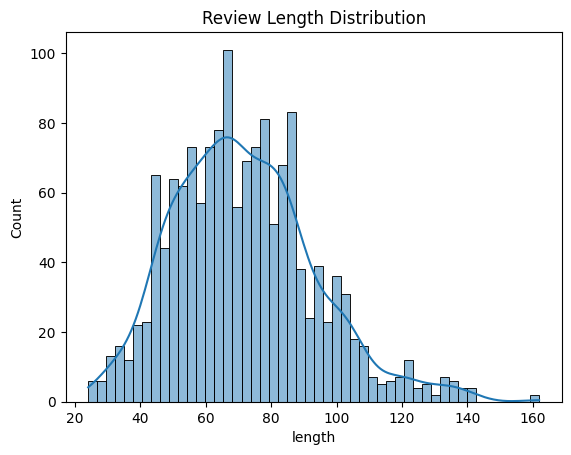

In [220]:
df['length'] = df['review_en'].apply(len)

sns.histplot(df['length'], bins=50, kde=True)
plt.title("Review Length Distribution")
plt.show()

In [221]:
conflict = df.groupby(['review_en', 'aspect'])['sentiment'].nunique()

conflict = conflict[conflict > 1]
print("Total conflict samples: ", len(conflict))

Total conflict samples:  8


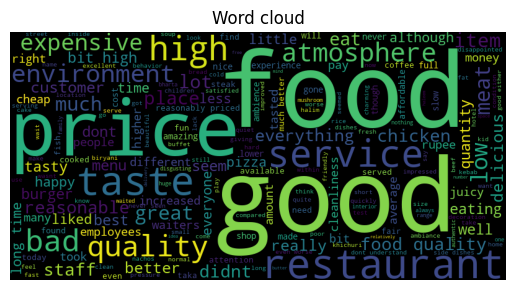

In [222]:
from wordcloud import WordCloud

text = " ".join(df['review_en'])

wc = WordCloud(width=800, height=400).generate(text)

plt.imshow(wc)
plt.axis('off')
plt.title("Word cloud")
plt.show()

In [223]:
positive_text = " ".join(df[df['sentiment']=='positive']['review_en'])
negative_text = " ".join(df[df['sentiment']=='negative']['review_en'])

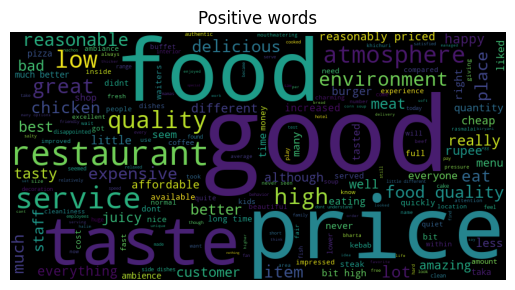

In [224]:
wc = WordCloud(width=800, height=400).generate(positive_text)

plt.imshow(wc)
plt.axis('off')
plt.title("Positive words")
plt.show()

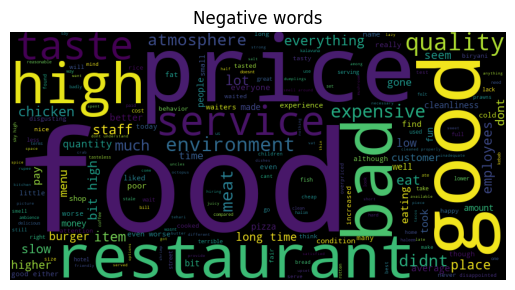

In [225]:
wc = WordCloud(width=800, height=400).generate(negative_text)

plt.imshow(wc)
plt.axis('off')
plt.title("Negative words")
plt.show()

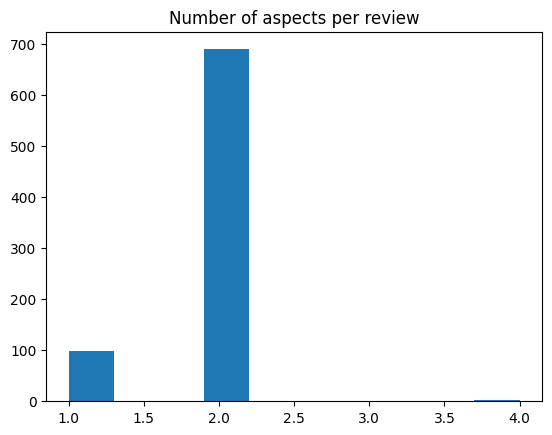

In [226]:
aspect_per_cmt = df.groupby('review_en')['aspect'].count()
plt.hist(aspect_per_cmt, bins=10)
plt.title("Number of aspects per review")
plt.show()

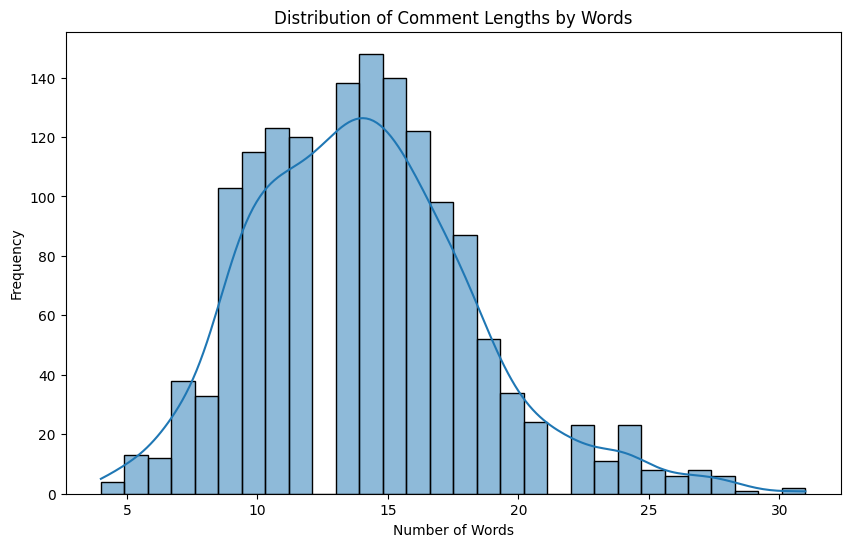

In [227]:
df['comment_length'] = df['review_en'].apply(lambda x: len(x.split()))
plt.figure(figsize=(10, 6))
sns.histplot(df['comment_length'], bins=30, kde=True)
plt.title('Distribution of Comment Lengths by Words')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()